Here it is given a basic tutorial of SVM with scikit learn.

In [1]:
%matplotlib widget
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# --- 1. Load a toy dataset (Iris, 2 classes only) ---
iris = datasets.load_iris()
# Keep only the first two classes (setosa vs versicolor) for binary classification
mask = iris.target != 2
X = iris.data[mask][:, :2]  # use first 2 features so it's easy to visualize
y = iris.target[mask]

# --- 2. Split into train / test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
 
# --- 3. Feature scaling (important for SVM) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
 
# --- 4. Train a linear SVM ---
# C controls the soft-margin trade-off:
#   large C  → narrower margin, fewer misclassifications (less regularisation)
#   small C  → wider margin, tolerates more misclassifications (more regularisation)
clf = SVC(kernel="linear", C=1.0)
clf.fit(X_train, y_train)

SVC(kernel='linear')

In [5]:
X.shape

(100, 2)

In [4]:
# --- 5. Evaluate ---
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["setosa", "versicolor"]))
 
# --- 6. Inspect the model ---
print("Weight vector (w):", clf.coef_)
print("Bias (b):         ", clf.intercept_)
print("Support vectors:  ", clf.n_support_)

Accuracy: 1.0

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        17
  versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Weight vector (w): [[ 1.90174734 -1.52515553]]
Bias (b):          [0.44557826]
Support vectors:   [5 5]


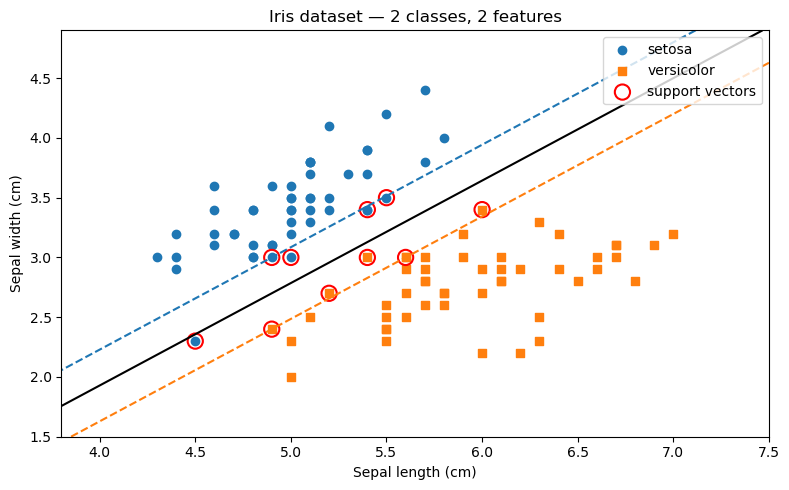

In [4]:
# Scatter plot — each colour is a class
plt.figure(figsize=(8, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="setosa", marker="o")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="versicolor", marker="s")
# --- Plot the decision boundary + margins ---
# After fitting the scaler and the SVM (clf), create a mesh over the plot area
# We need to scale the axes the same way we scaled the training data
 
# Build a grid in the original (unscaled) feature space
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
 
# Scale the grid points the same way the training data was scaled
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid_points)
 
# Get the decision function value at each grid point
Z = clf.decision_function(grid_scaled).reshape(xx.shape)
 
# Draw the decision boundary (Z=0) and the margins (Z=-1, Z=+1)
plt.contour(xx, yy, Z, levels=[-1, 0, 1],
            linestyles=["--", "-", "--"],
            colors=["tab:blue", "black", "tab:orange"])
 
# Highlight the support vectors
sv = scaler.inverse_transform(clf.support_vectors_)  # back to original scale
plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors="none",
            edgecolors="red", linewidths=1.5, label="support vectors")
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Iris dataset — 2 classes, 2 features")
plt.legend()
plt.tight_layout()

plt.show()


In [2]:
# --- 1. Load a toy dataset (Iris, 2 classes only) ---
breast = datasets.load_breast_cancer()
# Keep only the first three classes for binary classification
mask = breast.target != 3
X = breast.data[mask][:, :3]  # use first 3 features
y = breast.target[mask]

# --- 2. Split into train / test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
 
# --- 3. Feature scaling (important for SVM) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
 
# --- 4. Train a linear SVM ---
# C controls the soft-margin trade-off:
#   large C  → narrower margin, fewer misclassifications (less regularisation)
#   small C  → wider margin, tolerates more misclassifications (more regularisation)
clf = SVC(kernel="linear", C=1.0)
clf.fit(X_train, y_train)

SVC(kernel='linear')

In [13]:
print(breast.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


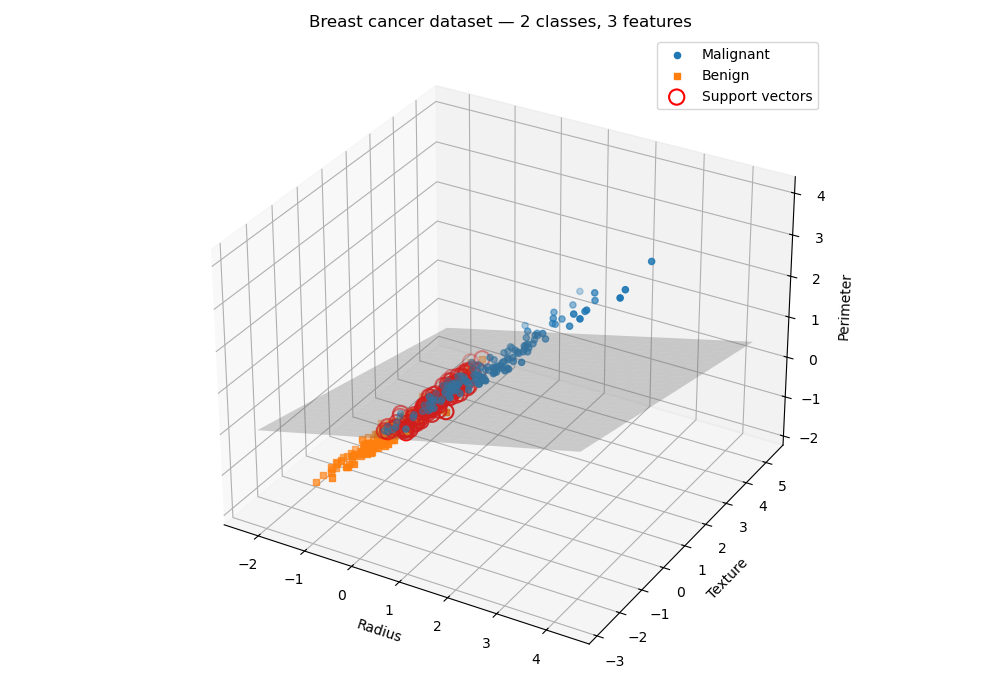

In [3]:
"""
# Scatter plot — each colour is a class
plt.figure(figsize=(8, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Malignant", marker="o")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Benign", marker="s")
# --- Plot the decision boundary + margins ---
# After fitting the scaler and the SVM (clf), create a mesh over the plot area
# We need to scale the axes the same way we scaled the training data
 
# Build a grid in the original (unscaled) feature space
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
z_min, z_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                      np.linspace(y_min, y_max, 100), np.linspace(z_min, z_max, 100))
 
# Scale the grid points the same way the training data was scaled
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid_points)
 
# Get the decision function value at each grid point
Z = clf.decision_function(grid_scaled).reshape(xx.shape)
 
# Draw the decision boundary (Z=0) and the margins (Z=-1, Z=+1)
plt.contour(xx, yy, Z, levels=[-1, 0, 1],
            linestyles=["--", "-", "--"],
            colors=["tab:blue", "black", "tab:orange"])
 
# Highlight the support vectors
sv = scaler.inverse_transform(clf.support_vectors_)  # back to original scale
plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors="none",
            edgecolors="red", linewidths=1.5, label="support vectors")
"""
 
# Separate the two classes
class_0 = X_train[y_train == 0]
class_1 = X_train[y_train == 1]
 
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
 
# Scatter the two classes
ax.scatter(class_0[:, 0], class_0[:, 1], class_0[:, 2],
           label="Malignant", marker="o")
ax.scatter(class_1[:, 0], class_1[:, 1], class_1[:, 2],
           label="Benign", marker="s")
 
# --- Plot the decision hyperplane ---
# The hyperplane equation is:  w[0]*x + w[1]*y + w[2]*z + b = 0
# Solving for z:  z = -(w[0]*x + w[1]*y + b) / w[2]
w = clf.coef_[0]
b = clf.intercept_[0]
 
# Create a grid over the x-y range of the data
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 30),
                      np.linspace(ylim[0], ylim[1], 30))
zz = -(w[0] * xx + w[1] * yy + b) / w[2]
 
# Draw the plane as a semi-transparent surface
ax.plot_surface(xx, yy, zz, alpha=0.3, color="gray")
 
# Highlight support vectors
sv = clf.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], sv[:, 2],
           s=120, facecolors="none", edgecolors="red",
           linewidths=1.5, label="Support vectors")
 
ax.set_xlabel("Radius")
ax.set_ylabel("Texture")
ax.set_zlabel("Perimeter")
ax.set_title("Breast cancer dataset — 2 classes, 3 features")
ax.legend()
plt.tight_layout()
plt.show()
